In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [46]:
df= pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [47]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [48]:
df.shape

(10000, 14)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [50]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [53]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [54]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [55]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [56]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [57]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [58]:
x= df.drop(columns=['Exited'])
y=df['Exited']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [59]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [60]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [61]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [62]:
x_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [82]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [85]:
model= Sequential()

model.add(Dense(11,activation= 'relu',input_dim=11))
model.add(Dense(11,activation= 'relu'))
model.add(Dense(1,activation= 'sigmoid'))

In [86]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.compile(loss='binary_crossentropy', optimizer= 'Adam',metrics=['accuracy'])

In [95]:
history= model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8680 - loss: 0.3222 - val_accuracy: 0.8569 - val_loss: 0.3393
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8717 - loss: 0.3221 - val_accuracy: 0.8594 - val_loss: 0.3393
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8702 - loss: 0.3217 - val_accuracy: 0.8569 - val_loss: 0.3388
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.3222 - val_accuracy: 0.8519 - val_loss: 0.3404
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8684 - loss: 0.3223 - val_accuracy: 0.8550 - val_loss: 0.3408
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8709 - loss: 0.3224 - val_accuracy: 0.8556 - val_loss: 0.3380
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8703 - loss: 0.3214 - val_accuracy: 0.8575 - val_loss: 0.3379
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8680 - loss: 0.3219 - val_accu

In [96]:
model.layers[0].get_weights()

[array([[ 0.15454191,  0.0036562 ,  0.107471  ,  0.23436439, -0.22783066,
          0.00940165, -0.05477213, -0.02081525,  0.114951  , -0.4021582 ,
         -0.27867764],
        [ 0.13866994,  0.12082721, -0.7357676 , -0.32856283, -0.26847035,
         -0.34524164, -0.94437784, -0.44174224, -0.24547192,  0.17686833,
          0.88706064],
        [ 0.19181411, -0.03044054,  0.08650935,  0.04435083, -0.46241292,
         -0.4842057 , -0.17141533, -0.03137613,  0.04343064, -0.10264207,
         -0.21350208],
        [-0.6548202 , -0.23671594, -0.3113905 , -0.06957736, -0.1389314 ,
          0.31743076, -0.14630063,  0.9004249 , -1.1152875 ,  0.27766177,
          0.06237809],
        [-0.48457116, -1.2136654 , -0.0836643 ,  1.5094545 , -0.20776603,
          0.6705562 ,  0.17822742, -0.1695755 ,  0.07619857,  0.5892683 ,
          0.7939365 ],
        [-0.0210045 ,  0.0127707 ,  0.36075124,  0.15681687, -0.5276781 ,
         -0.01792447, -0.08757893,  0.7446183 ,  0.09924779,  0.0536584

In [97]:
model.layers[1].get_weights()

[array([[-3.3575356e-01,  4.1975510e-01,  4.9236274e-01, -2.9910862e-01,
         -2.4244332e-01,  3.2398474e-01, -1.9821168e-01,  2.7239421e-01,
          5.3250939e-01,  7.7223486e-01,  3.3175088e-02],
        [-2.9674888e-01, -3.9260870e-01,  2.6212856e-01, -4.3057060e-01,
          4.9937633e-01,  4.6754923e-01,  4.8883110e-01, -1.0833692e-01,
         -4.0505588e-01, -4.1630447e-02, -4.1789496e-01],
        [ 5.0653088e-01,  2.3642354e-01,  2.8019285e-01, -1.4387838e-03,
         -7.7729124e-01, -2.7461749e-01, -1.4802299e-01, -4.2327067e-01,
         -2.9131012e-02, -3.1242406e-01, -5.1336992e-01],
        [-1.2848319e-01,  9.5499471e-02,  5.3149933e-01,  2.5637951e-01,
          1.8012618e-01, -1.8296645e+00,  8.0804378e-01,  4.4743749e-01,
          2.3507969e-01,  2.4485725e-01,  8.1626683e-01],
        [ 5.8506405e-01,  4.5702881e-01,  4.6474345e-02, -8.8804507e-01,
          6.4850241e-01,  1.8538319e-02,  5.1698085e-02, -2.0201595e-01,
         -4.1523792e-02, -3.8380182e-0

In [98]:
y_log=model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [102]:
y_pred= np.where(y_log>0.5,1,0)

In [103]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.865

In [105]:
import matplotlib.pyplot as plt

In [106]:
history.history

{'accuracy': [0.867968738079071,
  0.8717187643051147,
  0.8701562285423279,
  0.8687499761581421,
  0.8684375286102295,
  0.8709375262260437,
  0.870312511920929,
  0.867968738079071,
  0.870312511920929,
  0.8696874976158142,
  0.8685937523841858,
  0.8701562285423279,
  0.8685937523841858,
  0.8700000047683716,
  0.8700000047683716,
  0.8695312738418579,
  0.8707812428474426,
  0.8700000047683716,
  0.8693749904632568,
  0.8707812428474426,
  0.8700000047683716,
  0.8693749904632568,
  0.8693749904632568,
  0.8693749904632568,
  0.8707812428474426,
  0.870312511920929,
  0.8684375286102295,
  0.8692187666893005,
  0.8715624809265137,
  0.870312511920929,
  0.8700000047683716,
  0.8698437213897705,
  0.8700000047683716,
  0.8685937523841858,
  0.8700000047683716,
  0.8715624809265137,
  0.8706250190734863,
  0.8709375262260437,
  0.8698437213897705,
  0.8687499761581421,
  0.8701562285423279,
  0.8712499737739563,
  0.8709375262260437,
  0.8690624833106995,
  0.8704687356948853,
  0.

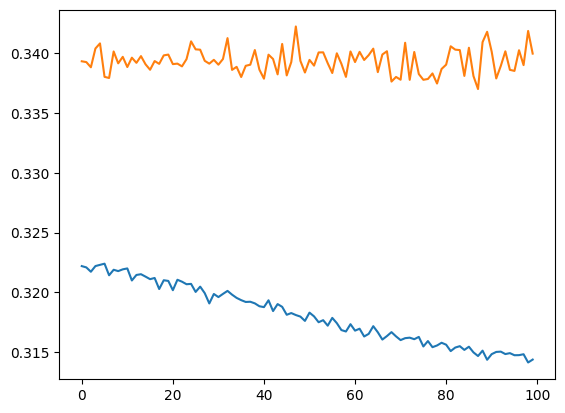

In [108]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])